In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy
import pickle
import random
import seaborn as sns
import matplotlib.ticker as ticker


from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [59]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                mean_abs_cntrl = np.mean( [max_cntrl_[v], np.abs(min_cntrl_[v])] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_abs_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 50.
min_c_c = - 50.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [2]:
params_bistability_exc = []
params_bistability_inh = []

8
[2.55, 2.3000000000000003, 2.5]
[2.4, 2.0, 2.0]


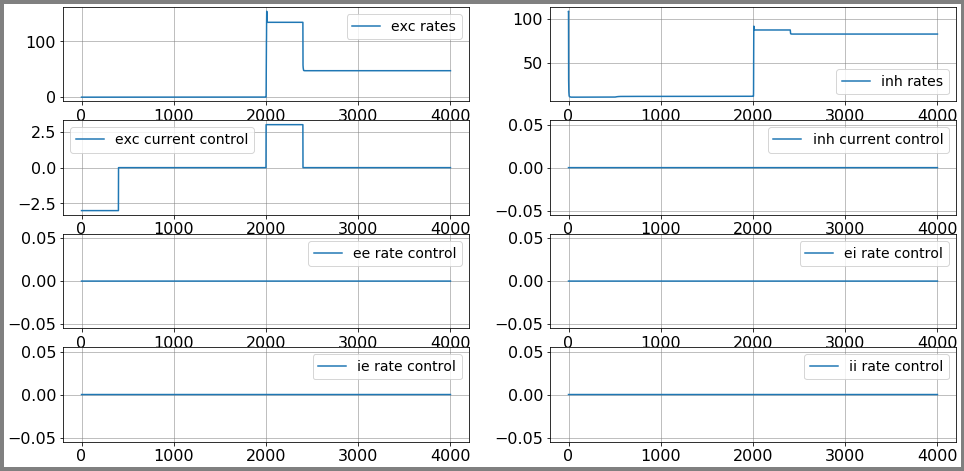

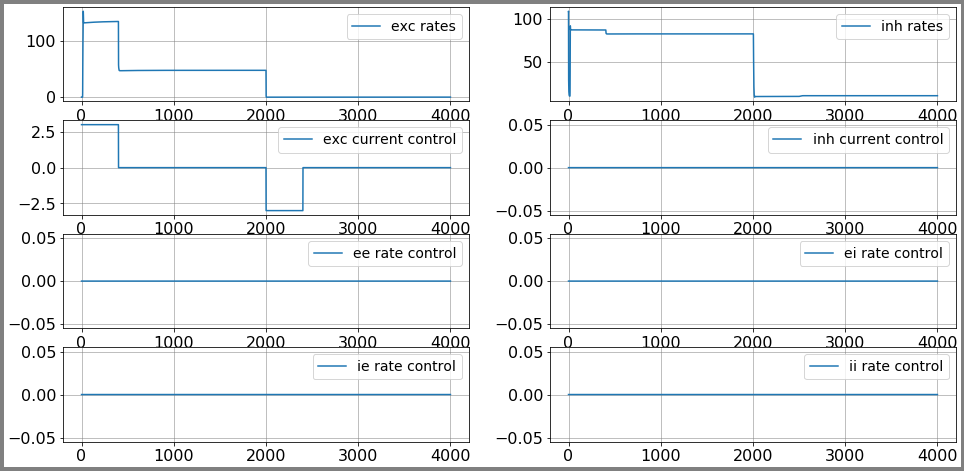

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


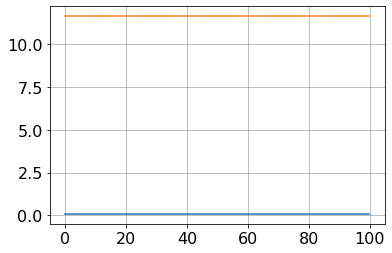

In [61]:
#params_bistability_exc.pop()
#params_bistability_inh.pop()

print(len(params_bistability_exc))
print(params_bistability_exc[-3:])
print(params_bistability_inh[-3:])

aln.params['duration'] = 4000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 3.)

aln.params.ext_exc_current = 0.5 * 5.
aln.params.ext_inh_current = 0.4 * 5.
# bistable -0.16

# 3.65 7.4

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
steady_rates[1,0] = aln.rates_exc[0,-1] # low state exc
steady_rates[1,1] = aln.rates_inh[0,-1] # low state inh

print(steady_rates)

plt.plot(np.arange(0,100, 0.1), aln.rates_exc[0,-1000:])      
plt.plot(np.arange(0,100, 0.1), aln.rates_inh[0,-1000:])


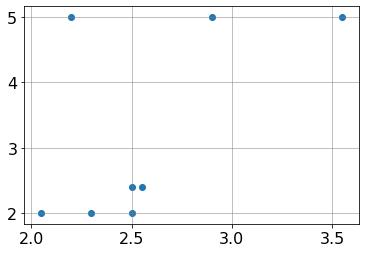

In [25]:
params_bistability_exc.append(aln.params.ext_exc_current)
params_bistability_inh.append(aln.params.ext_inh_current)
plt.scatter(params_bistability_exc, params_bistability_inh)

In [26]:
#params_bistability_exc.pop()
#params_bistability_inh.pop()

with open('bistability_exc_inh.pickle','wb') as f:
    pickle.dump([params_bistability_exc, params_bistability_inh], f)
    
with open('bistability_exc_inh.pickle','rb') as f:
    load_array = pickle.load(f)
    
print(load_array)

[[2.2, 2.9, 3.55, 2.05, 2.5, 2.55, 2.3000000000000003, 2.5], [5.0, 5.0, 5.0, 2.0, 2.4, 2.4, 2.0, 2.0]]


In [27]:
with open('bistability_exc_inh.pickle','rb') as f:
    load_array = pickle.load(f)
    
params_bistability_exc = load_array[0]
params_bistability_inh = load_array[1]
    
print(load_array)

[[2.2, 2.9, 3.55, 2.05, 2.5, 2.55, 2.3000000000000003, 2.5], [5.0, 5.0, 5.0, 2.0, 2.4, 2.4, 2.0, 2.0]]


In [28]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

bestControl_init = [None] * len(params_bistability_exc)
bestState_init = [None] * len(params_bistability_exc)
cost_init = [None] * len(params_bistability_exc)
runtime_init = [None] * len(params_bistability_exc)
grad_init = [None] * len(params_bistability_exc)
phi_init = [None] * len(params_bistability_exc)
costnode_init = [None] * len(params_bistability_exc)
weights_init = [None] * len(params_bistability_exc)

initVars = [None] * len(params_bistability_exc)
target = [None] * len(params_bistability_exc)
cost_uncontrolled = [None] * len(params_bistability_exc)

bestControl_0 = [None] * len(params_bistability_exc)
bestState_0 = [None] * len(params_bistability_exc)
cost_0 = [None] * len(params_bistability_exc)
runtime_0 = [None] * len(params_bistability_exc)
grad_0 = [None] * len(params_bistability_exc)
phi_0 = [None] * len(params_bistability_exc)
costnode_0 = [None] * len(params_bistability_exc)
weights_0 = [None] * len(params_bistability_exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

print(len(weights_init))

8


In [63]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

sheet = "state_switching"
max_it = 2000

# done: 0,5,10,15,20
# inh only: 0,5,10,15,20

#target = [None] * len(params_bistability_exc)

-------  0 2.2 5.0


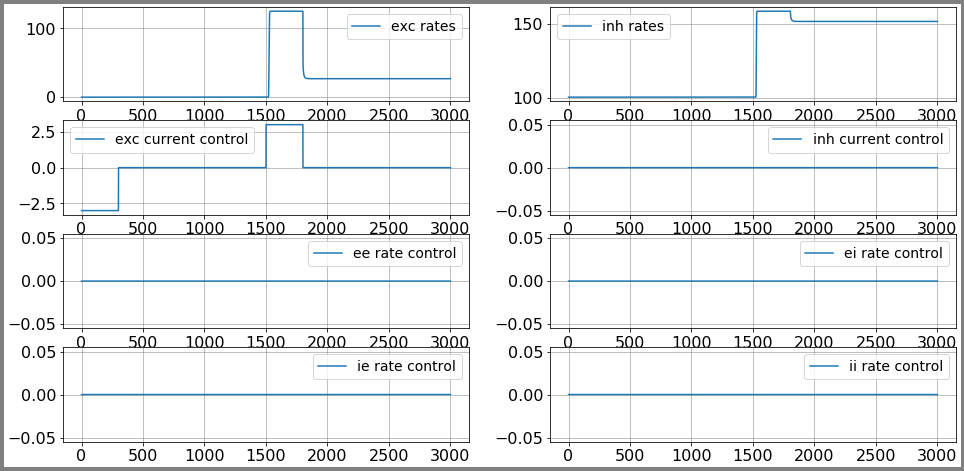

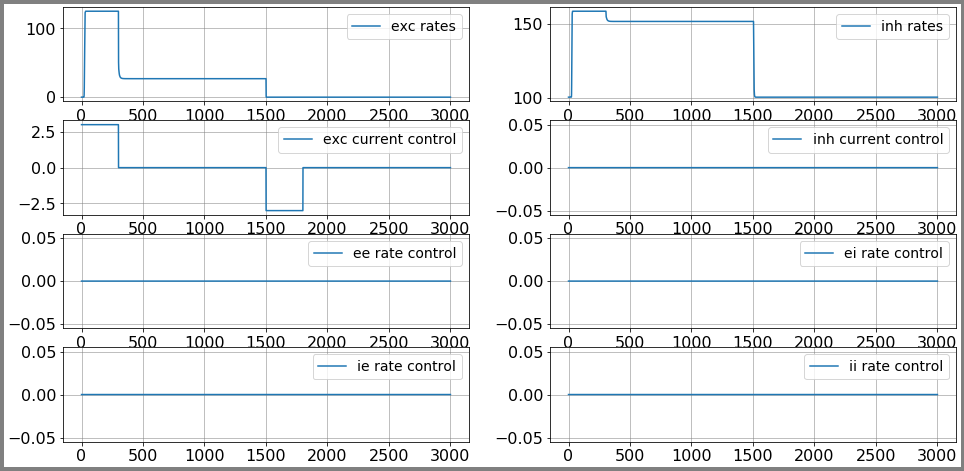

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7200.017625148343
Gradient descend method:  None
RUN  0 , total integrated cost =  7200.017625148343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7270.7283032669975
Gradient descend method:  HS
RUN  1 , total integrated cost =  7201.9783032669975
RUN  2 , total integrated cost =  7200.0251782669975
RUN  3 , total integrated cost =  7200.017701424219
RUN  4 , total integrated cost =  7200.017701424219
Control only changes marginally.
RUN  4 , total integrated cost =  7200.017701424219
Improved over  4  iterations in  0.08859109999957582  seconds by  0.9725380855038424  percent.
weight sparsity =  9.999999894061544
set cost params:  1.0 0.0 9.999999894061544
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7200.017701424218
G

ERROR:root:Problem in initial value trasfer


RUN  180 , total integrated cost =  115.267842143955
Control only changes marginally.
RUN  181 , total integrated cost =  115.267842143955
Improved over  181  iterations in  4.045353700000305  seconds by  98.39906168395733  percent.
Problem in initial value trasfer:  Vmean_exc -55.59023581816098 -55.59023832242817
-------  1 2.9 5.0


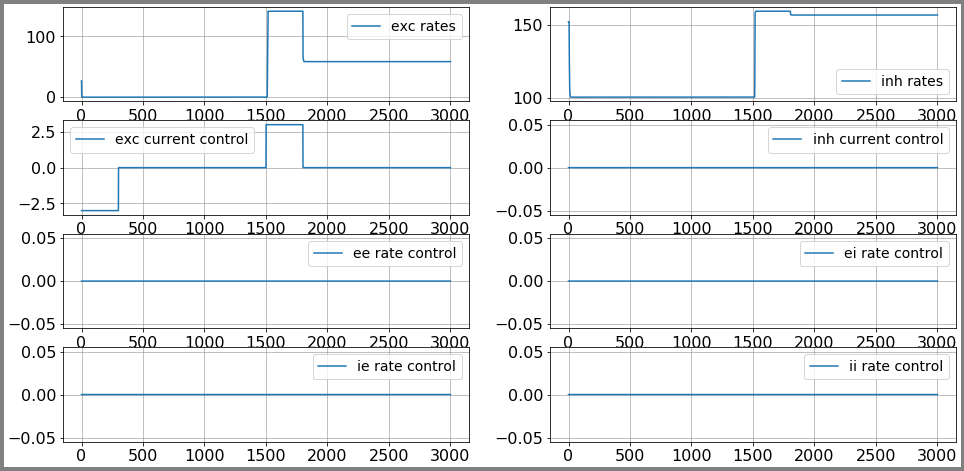

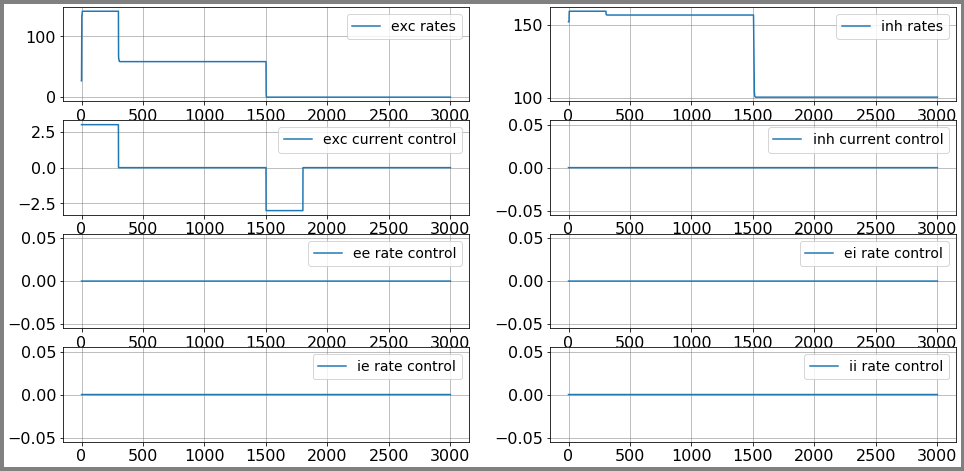

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34162.30683565532
Gradient descend method:  None
RUN  0 , total integrated cost =  34162.30683565532
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34233.01751377397
Gradient descend method:  HS
RUN  1 , total integrated cost =  34164.26751377397
RUN  2 , total integrated cost =  34162.31438877397
RUN  3 , total integrated cost =  34162.3069119312
RUN  4 , total integrated cost =  34162.3069119312
Control only changes marginally.
RUN  4 , total integrated cost =  34162.3069119312
Improved over  4  iterations in  0.09194579999984853  seconds by  0.20655673083544457  percent.
weight sparsity =  9.999999977672504
set cost params:  1.0 0.0 9.999999977672504
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34162.3069119312
Gradien

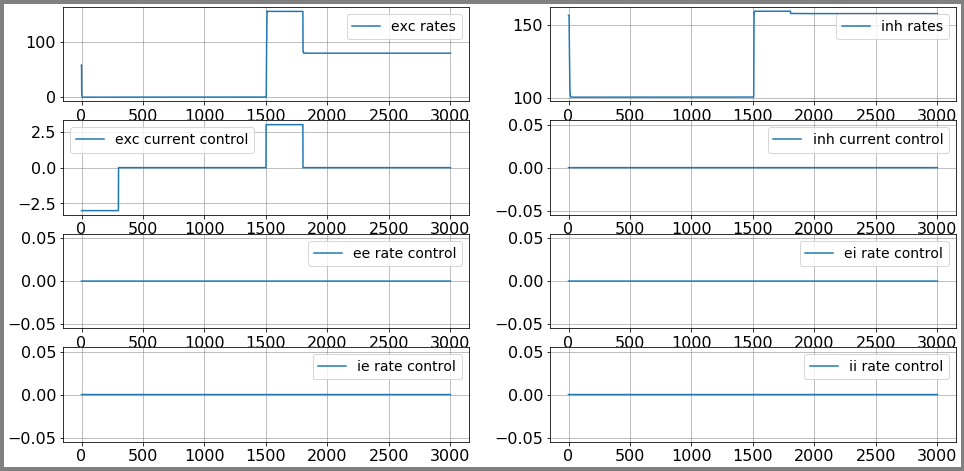

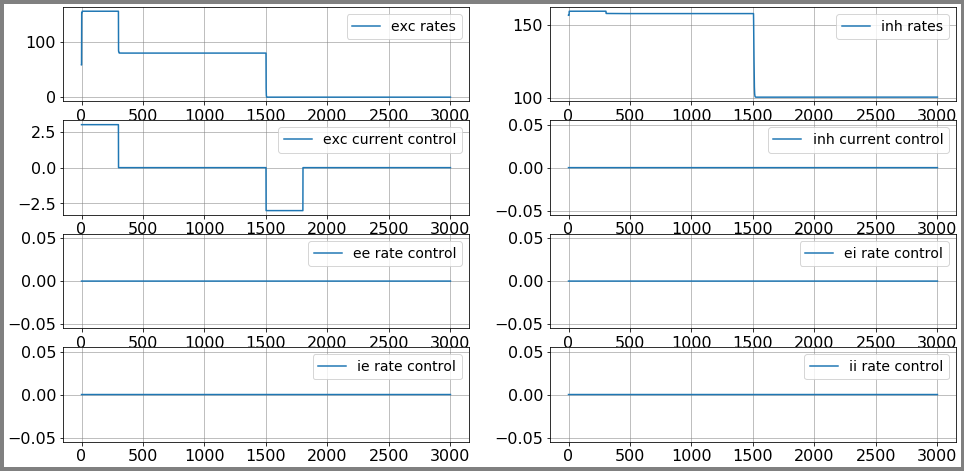

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63725.207233421395
Gradient descend method:  None
RUN  0 , total integrated cost =  63725.207233421395
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  70.71068060099263
Gradient descend method:  HS
RUN  1 , total integrated cost =  70.31480132623115
RUN  2 , total integrated cost =  62.19231510168423
RUN  3 , total integrated cost =  62.09197187439326
RUN  4 , total integrated cost =  60.46420899716284
RUN  5 , total integrated cost =  59.98583863966339
RUN  6 , total integrated cost =  59.98583863966337
RUN  7 , total integrated cost =  59.97774576593301
RUN  8 , total integrated cost =  59.66920299717956
RUN  9 , total integrated cost =  59.587246102505226
RUN  10 , total integrated cost =  59.580822501430546
RUN  11 , total integrated cost =  59.

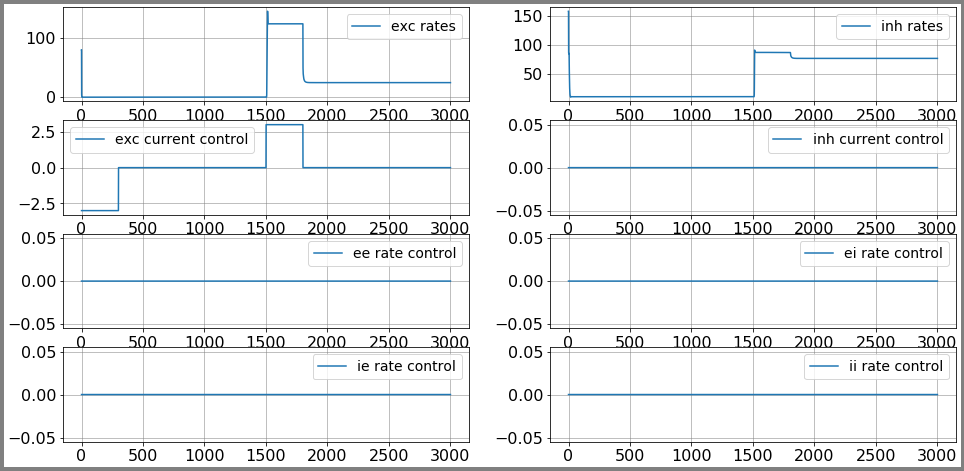

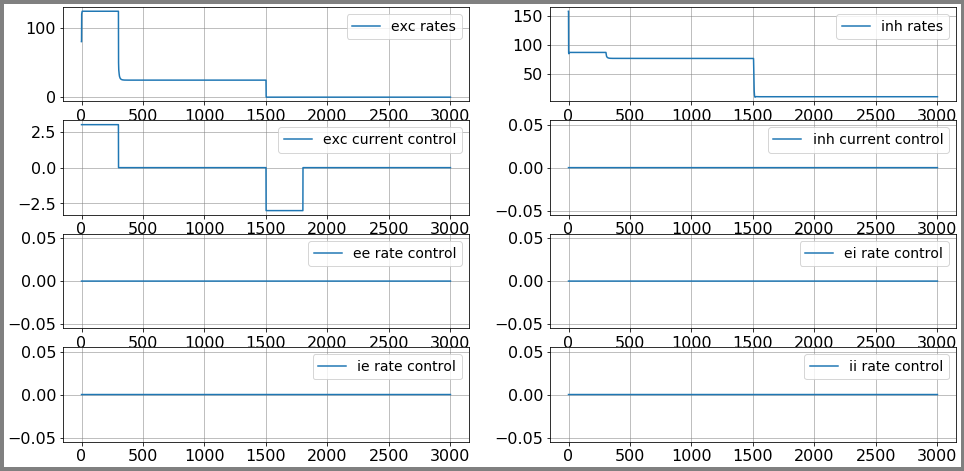

ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6003.752304664325
Gradient descend method:  None
RUN  0 , total integrated cost =  6003.752304664325
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6074.462982425136
Gradient descend method:  HS
RUN  1 , total integrated cost =  6005.712983308012
RUN  2 , total integrated cost =  170.50325877718848
RUN  3 , total integrated cost =  170.50325877718848
Control only changes marginally.
RUN  3 , total integrated cost =  170.50325877718848
Improved over  3  iterations in  0.13840280000022176  seconds by  97.19311387244444  percent.
Problem in initial value trasfer:  Vmean_exc -55.464688331561035 -55.46468631728879
weight sparsity =  352.1195047955038
set cost params:  1.0 0.0 352.1195047955038
interpolate adjoint :  True True True
RUN  0 , total integra

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  1139.344649349194
RUN  200 , total integrated cost =  1139.344649349194
Improved over  200  iterations in  4.460850100000243  seconds by  81.02257829357399  percent.
Problem in initial value trasfer:  Vmean_exc -55.4512226727791 -55.451341151298536
-------  4 2.5 2.4


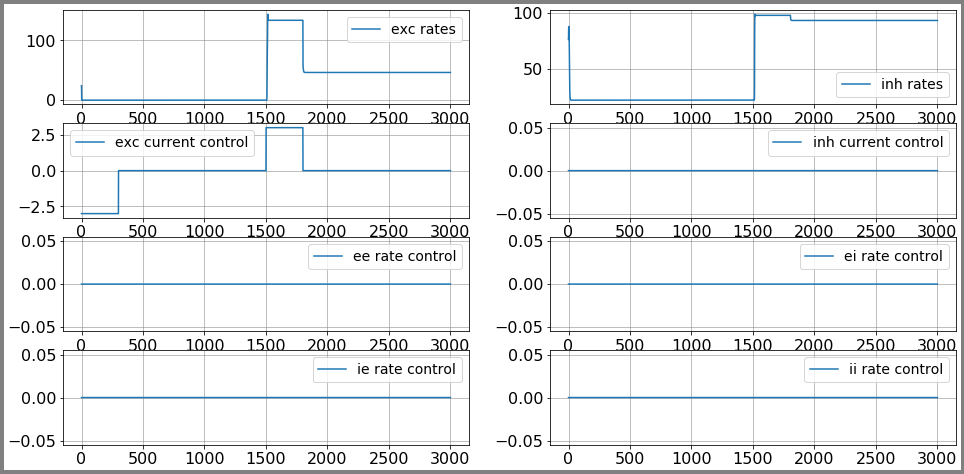

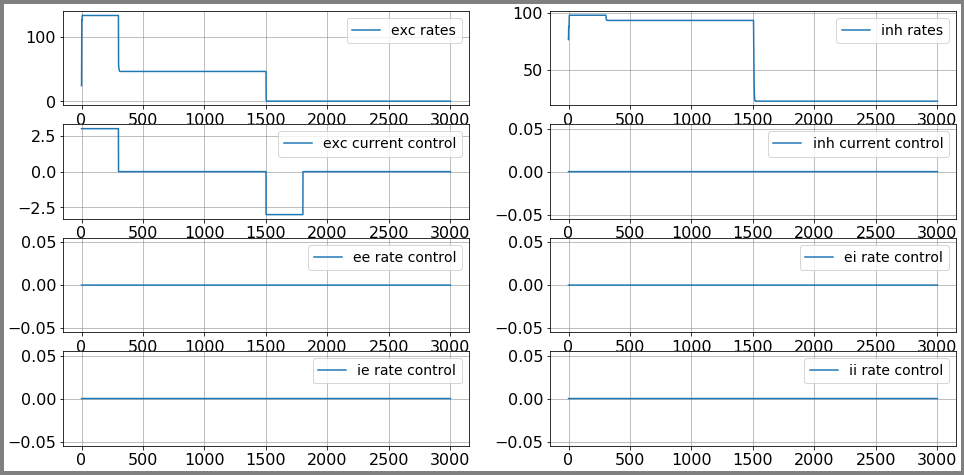

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21548.557196523256
Gradient descend method:  None
RUN  0 , total integrated cost =  21548.557196523256
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21619.26787464191
Gradient descend method:  HS
RUN  1 , total integrated cost =  21550.51787464191
RUN  2 , total integrated cost =  21548.56474964191
RUN  3 , total integrated cost =  21548.55727279913
RUN  4 , total integrated cost =  21548.55727279913
Control only changes marginally.
RUN  4 , total integrated cost =  21548.55727279913
Improved over  4  iterations in  0.10763969999970868  seconds by  0.3270721388568347  percent.
weight sparsity =  9.999999964602791
set cost params:  1.0 0.0 9.999999964602791
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21548.55727279913
Gr

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  36.878723390859854
RUN  200 , total integrated cost =  36.878723390859854
Improved over  200  iterations in  4.579674999999952  seconds by  99.82885757536347  percent.
Problem in initial value trasfer:  Vmean_exc -56.15837343659398 -56.158373379892794
-------  5 2.55 2.4


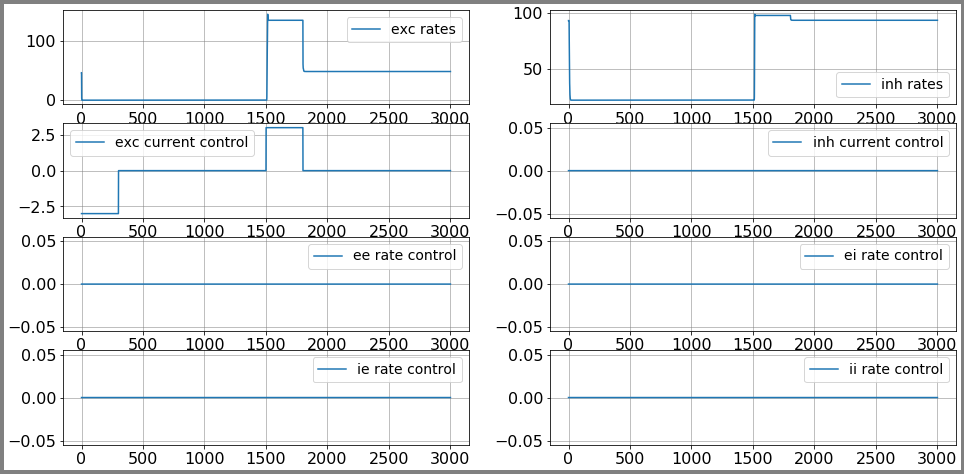

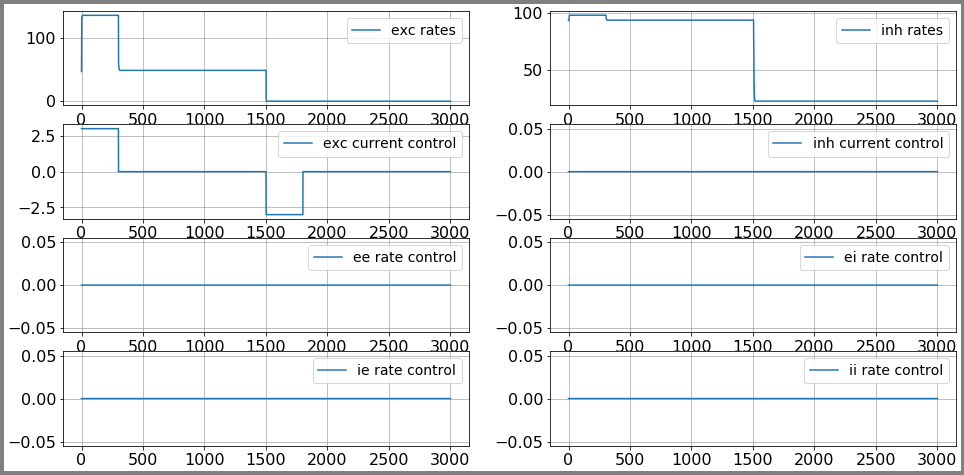

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23446.609381733528
Gradient descend method:  None
RUN  0 , total integrated cost =  23446.609381733528
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23517.32005985218
Gradient descend method:  HS
RUN  1 , total integrated cost =  23448.57005985219
RUN  2 , total integrated cost =  23446.61693485219
RUN  3 , total integrated cost =  23446.609458009396
RUN  4 , total integrated cost =  23446.609458009396
Control only changes marginally.
RUN  4 , total integrated cost =  23446.609458009396
Improved over  4  iterations in  0.1286076000005778  seconds by  0.30067457373044704  percent.
weight sparsity =  9.999999967468273
set cost params:  1.0 0.0 9.999999967468273
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23446.60945800939

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  59.45500391496062
RUN  200 , total integrated cost =  59.45500391496062
Improved over  200  iterations in  8.484273400000347  seconds by  99.7464238741152  percent.
Problem in initial value trasfer:  Vmean_exc -56.186939489435474 -56.186939602114094
-------  6 2.3000000000000003 2.0


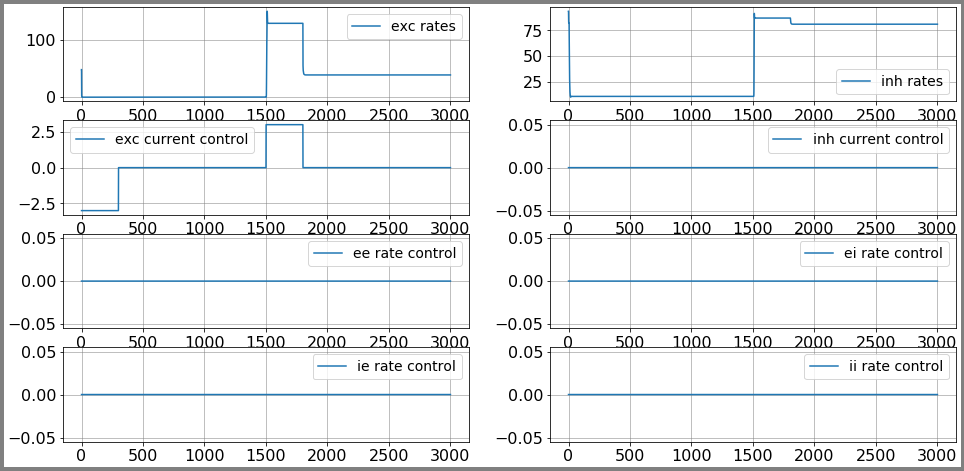

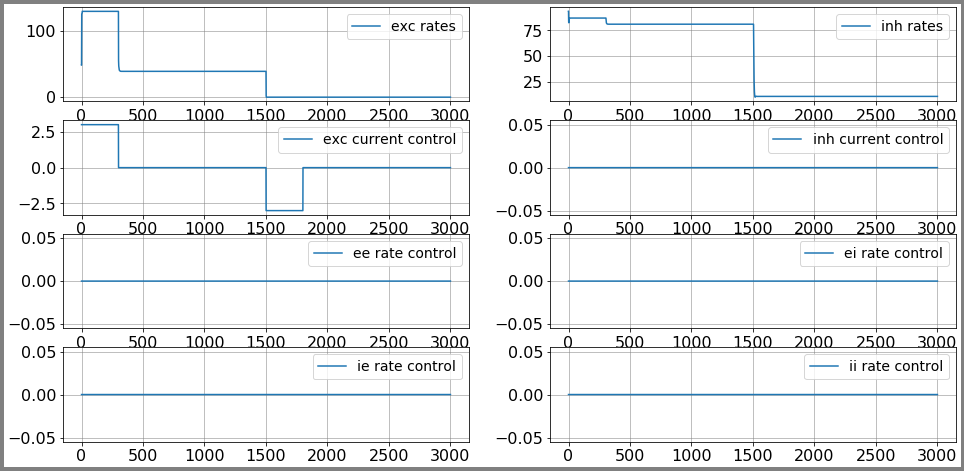

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15221.808757029406
Gradient descend method:  None
RUN  0 , total integrated cost =  15221.808757029406
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  70.71067811865538
Gradient descend method:  HS
RUN  1 , total integrated cost =  48.83577038012044
RUN  2 , total integrated cost =  48.42684150154006
RUN  3 , total integrated cost =  21.084769511360967
RUN  4 , total integrated cost =  20.187780384780346
RUN  5 , total integrated cost =  14.693457031863039
RUN  6 , total integrated cost =  14.245824454954148
RUN  7 , total integrated cost =  14.245824454953903
RUN  8 , total integrated cost =  14.06436601865211
RUN  9 , total integrated cost =  12.634813302205718
RUN  10 , total integrated cost =  12.612426897043544
RUN  11 , total integrated cost =

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  11.348382858315299
RUN  200 , total integrated cost =  11.348382858315299
Improved over  200  iterations in  6.398147599999902  seconds by  83.9509630507683  percent.
Problem in initial value trasfer:  Vmean_exc -56.018591780567235 -56.0185917250179
weight sparsity =  13413.196353237177
set cost params:  1.0 0.0 13413.196353237177
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15197.154685824056
Gradient descend method:  None
RUN  1 , total integrated cost =  15079.39797989379
RUN  2 , total integrated cost =  15079.322566707997
RUN  3 , total integrated cost =  15079.253524371221
RUN  4 , total integrated cost =  15079.184260599593
RUN  5 , total integrated cost =  15079.112329216123
RUN  6 , total integrated cost =  15079.034012529099
RUN  7 , total integrated cost =  15078.971178548656
RUN  8 , total integrated cost =  15078.902912213998
RUN  9 , total integrated cost =  15078.829008593855
RUN  10 , total integrated cost =

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  15066.056445454418
RUN  200 , total integrated cost =  15066.056445454418
Improved over  200  iterations in  4.727858099999139  seconds by  0.8626499044056288  percent.
Problem in initial value trasfer:  Vmean_exc -56.0182744380047 -56.018283306666824
-------  7 2.5 2.0


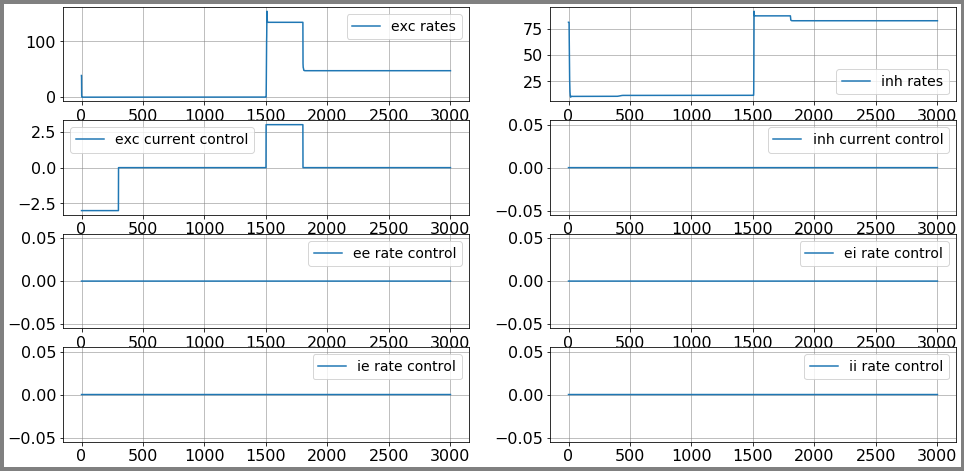

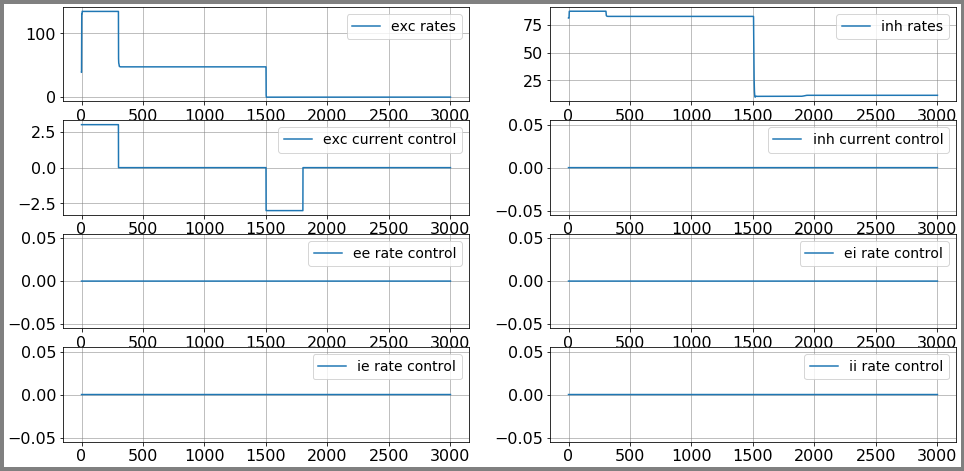

set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  0 , total integrated cost =  22493.494361608944
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  70.71067811865476
Gradient descend method:  HS
RUN  1 , total integrated cost =  11.335678118654762
RUN  2 , total integrated cost =  9.96850647914194
RUN  3 , total integrated cost =  4.987793354486284
RUN  4 , total integrated cost =  4.698333066420605
RUN  5 , total integrated cost =  4.698333066420605
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  4.698333066420605
Improved over  5  iterations in  0.20428139999967243  seconds by  93.35555365692201  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459807413996 -56.17459779522289
weight sparsity =  47875.4784805954
set cost params:  1.0 0.0 47875.4784805954
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22353.119582658477
Gradient descend method:  None
RUN  1 , total integrated cost =  22263.546142731837
RUN  2 , total integrated cost =  22262.39667835177
RUN  3 , total integrated cost =  22258.975115538942
RUN  4 , total integrated cost =  22256.593801539417
RUN  5 , total integrated cost =  22254.42621428029
RUN  6 , total integrated cost =  22253.04189653444
RUN  7 , total integrated cost =  22251.830603302573
RUN  8 , total integrated cost =  22251.00759236233
RUN  9 , total integrated cost =  22249.755895605635
RUN  10 , total integrated cost =  22248.84289544756
RUN  11 , total integrated cost =  22246.563

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  20424.23632786623
RUN  200 , total integrated cost =  20424.23632786623
Improved over  200  iterations in  5.658976700000494  seconds by  8.629145688858003  percent.
Problem in initial value trasfer:  Vmean_exc -56.174582891618364 -56.17458321361571


In [120]:
cntrl_vars = c_var[1]
prec_vars = p_var[0]

trans_time = trans_time_array[0]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

i_range = range(len(params_bistability_exc))

factor_iteration = 2

for i in i_range:
    print("------- ", i, params_bistability_exc[i], params_bistability_inh[i])
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = step_control(maxI_ = 3.)

    plotFunc.plot_traces(aln, control0)
    
    steady_rates = np.zeros((2, 2))
    steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
    steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh

    control0 = step_control(maxI_ = -3.)
    plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")

    low_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            low_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            low_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = low_state_vars
    
    aln.params.duration = dur

    # set low state rates as target
    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = steady_rates[0,0]
    target[i][:,1,:] = steady_rates[0,1]
    
    case = sheet + str(0) + "_init"
    
    cost.setParams(1.0, 0.0, 1.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()
    #control0[0,0,:200] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init[i][0]
    
##### initial guess
    weight_s = 10
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0[0,1,:20] = -5.

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_s = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

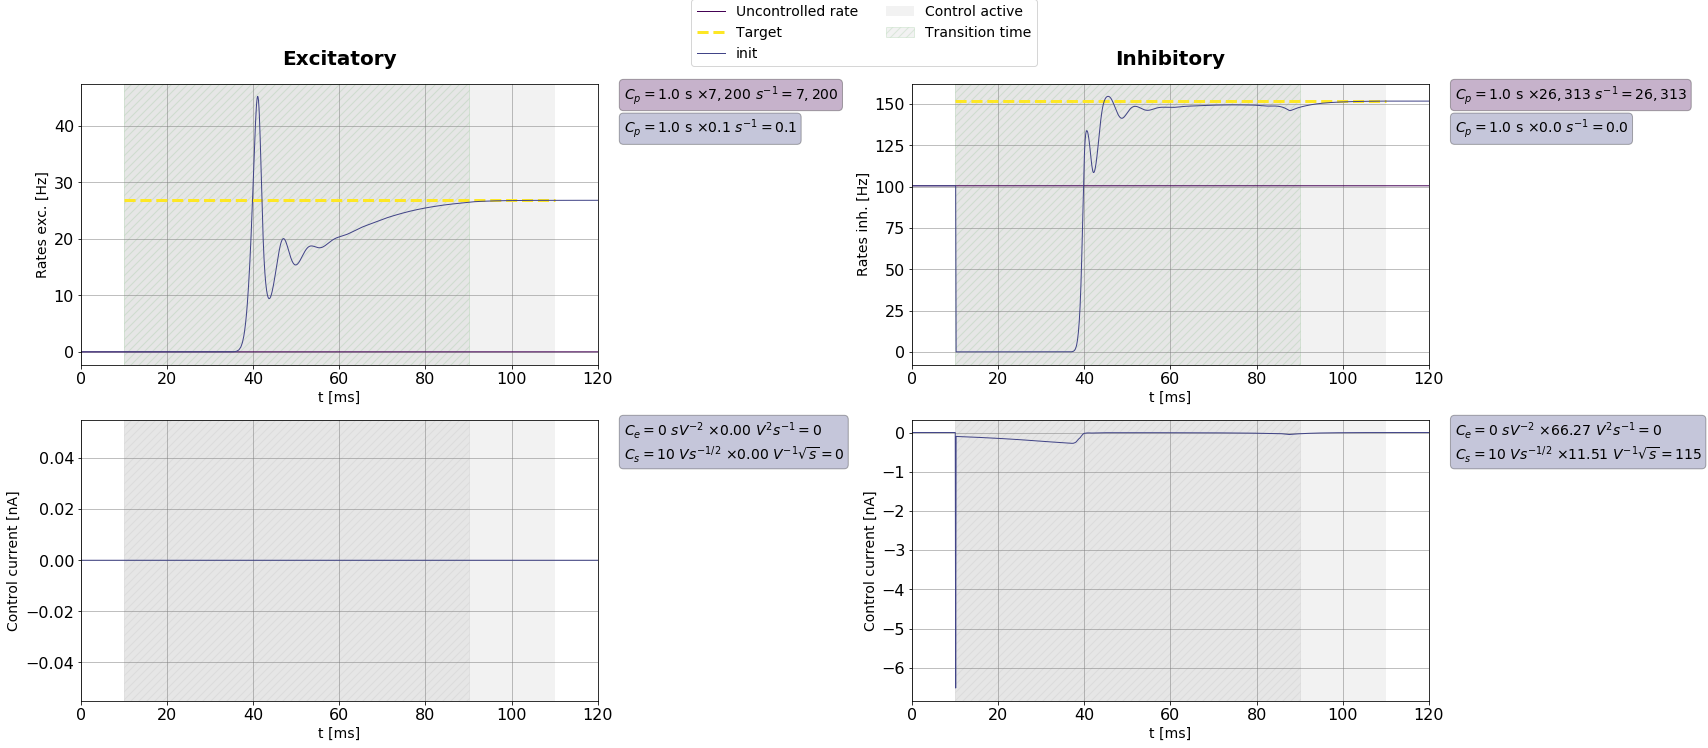

In [119]:
#plot initial guesses

for i in i_range:
    
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], path, filename_ = case, transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)])

In [127]:
factor_iteration = 5
    
for i in i_range:
    print("------- ", i, params_bistability_exc[i], params_bistability_inh[i])
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_s = weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j] - 1
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 250 * factor_iteration )

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


-------  0 2.2 5.0
weight sparsity =  627.5406182573612
set cost params:  1.0 0.0 627.5406182573612
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7188.5624901642095
Gradient descend method:  None
RUN  1 , total integrated cost =  7188.5624901642095
Control only changes marginally.
RUN  1 , total integrated cost =  7188.5624901642095
Improved over  1  iterations in  0.07024000000092201  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.57800323845049 -55.57813331797938
-------  1 2.9 5.0
weight sparsity =  5702.182582015851
set cost params:  1.0 0.0 5702.182582015851
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34156.31679301783
Gradient descend method:  None
RUN  1 , total integrated cost =  34156.31679301783
Control only changes marginally.
RUN  1 , total integrated cost =  34156.31679301783
Improved over  1  iterations in  0.0750506000003952  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmea

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  63719.345547276374
Control only changes marginally.
RUN  1 , total integrated cost =  63719.345547276374
Improved over  1  iterations in  0.0770143999998254  seconds by  0.0  percent.
-------  3 2.05 2.0
weight sparsity =  2630.078893198144
set cost params:  1.0 0.0 2630.078893198144
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6001.470445164818
Gradient descend method:  None
RUN  1 , total integrated cost =  6001.470445164818
Control only changes marginally.
RUN  1 , total integrated cost =  6001.470445164818
Improved over  1  iterations in  0.06244630000037432  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.424835096383546 -55.42518646572895
-------  4 2.5 2.4
weight sparsity =  6916.319840384628
set cost params:  1.0 0.0 6916.319840384628
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21545.441998785096
Gradient descend method:  None
RUN  1 , total integrated cost =  215

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23443.71805366047
Control only changes marginally.
RUN  1 , total integrated cost =  23443.71805366047
Improved over  1  iterations in  0.06713560000025609  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.18691757174962 -56.18691849993132
-------  6 2.3000000000000003 2.0
weight sparsity =  13614.740748087295
set cost params:  1.0 0.0 13614.740748087295
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15220.69080031749
Gradient descend method:  None
RUN  1 , total integrated cost =  15220.69080031749
Control only changes marginally.
RUN  1 , total integrated cost =  15220.69080031749
Improved over  1  iterations in  0.07032280000021274  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.01812444428744 -56.01813754357068
-------  7 2.5 2.0
weight sparsity =  55121.819827937696
set cost params:  1.0 0.0 55121.819827937696
interpolate adjoint :  True True True
RUN  0 , total integra

In [128]:
with open('control_init_inh_lh.pickle','wb') as f:
    pickle.dump([bestControl_init, costnode_init, weights_init], f)
    
with open('control_init_inh_lh.pickle','rb') as f:
    load_array = pickle.load(f)
    
print(len(load_array))

#bestControl_init = load_array[0]
#costnode_init = load_array[1]
#weights_init = load_array[2]

3


In [152]:
case = sheet + str(0) + "_sparse_control"
cntrl_vars = c_var[2]
prec_vars = p_var[2]

trans_time = trans_time_array[2]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

factor_iteration = 10
    
for i in [0,1]:
    print("------- ", i, params_bistability_exc[i], params_bistability_inh[i])
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 25 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = 100
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 25 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 250 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 2.2 5.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  122.94263901198701
Gradient descend method:  None
RUN  1 , total integrated cost =  114.9654246408693
RUN  2 , total integrated cost =  114.89603966290517
RUN  3 , total integrated cost =  114.84750926026612
RUN  4 , total integrated cost =  114.82089998175229
RUN  5 , total integrated cost =  114.80329256005784
RUN  6 , total integrated cost =  114.78698746221534
RUN  7 , total integrated cost =  114.77398261605329
RUN  8 , total integrated cost =  114.76513417095819
RUN  9 , total integrated cost =  114.75804912951399
RUN  10 , total integrated cost =  114.75120031711114
RUN  11 , total integrated cost =  114.74529440180872
RUN  12 , total integrated cost =  114.7409653943481
RUN  13 , total integrated cost =  114.73676230857123
RUN  14 , total integrated cost =  114.73315787238684
RUN  15 , total integrated cost =  114.7287857354583
RUN  16 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  250 , total integrated cost =  114.48078987213759
Improved over  250  iterations in  11.364951499999734  seconds by  6.882761918771223  percent.
Problem in initial value trasfer:  Vmean_exc -55.59075684370891 -55.59075644767109
weight sparsity =  100
set cost params:  1.0 0.0 100
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1144.7166105613549
Gradient descend method:  HS
RUN  1 , total integrated cost =  1144.409590342393
RUN  2 , total integrated cost =  1144.3223770684824
RUN  3 , total integrated cost =  1144.2255489645331
RUN  4 , total integrated cost =  1144.2003525070425
RUN  5 , total integrated cost =  1144.1992440533766
RUN  6 , total integrated cost =  1144.1918632825075
RUN  7 , total integrated cost =  1144.1843146624144
RUN  8 , total integrated cost =  1144.1799185835825
RUN  9 , total integrated cost =  1144.1797306486258
RUN  10 , total integrated cost =  1144.176481861655
RUN  11 , total integrated cost =  1144.1715155389497
RUN  12 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  205 , total integrated cost =  1142.9438110258402
Improved over  205  iterations in  13.123825900000156  seconds by  0.1548679838449516  percent.
Problem in initial value trasfer:  Vmean_exc -55.58979255789106 -55.58980385317868
weight sparsity =  628.9537698783306
set cost params:  1.0 0.0 628.9537698783306
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7186.789208774348
Gradient descend method:  None
RUN  1 , total integrated cost =  7183.967943865801
RUN  2 , total integrated cost =  7183.822062558843
RUN  3 , total integrated cost =  7183.660060626404
RUN  4 , total integrated cost =  7183.543725574615
RUN  5 , total integrated cost =  7183.434708684143
RUN  6 , total integrated cost =  7183.351275826761
RUN  7 , total integrated cost =  7183.243832139971
RUN  8 , total integrated cost =  7183.18256816375
RUN  9 , total integrated cost =  7183.054837200254
RUN  10 , total integrated cost =  7182.993206449168
RUN  11 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  847 , total integrated cost =  7159.4182124499375
Improved over  847  iterations in  51.30985269999837  seconds by  0.3808515253375333  percent.
Problem in initial value trasfer:  Vmean_exc -55.589864677763046 -55.58986379021868
-------  1 2.9 5.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  60.29941306579387
Gradient descend method:  None
RUN  1 , total integrated cost =  59.90752177903299
RUN  2 , total integrated cost =  59.907508133060915
RUN  3 , total integrated cost =  59.90750812209849
RUN  4 , total integrated cost =  59.90750798890521
RUN  5 , total integrated cost =  59.90750792289018
RUN  6 , total integrated cost =  59.90750790756213
RUN  7 , total integrated cost =  59.907507792377835
RUN  8 , total integrated cost =  59.907507736404334
RUN  9 , total integrated cost =  59.90750771909816
RUN  10 , total integrated cost =  59.9075076017574
RUN  11 , total integrated cost =  59.9

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3 , total integrated cost =  34154.16756792633
Improved over  3  iterations in  0.6125612000014371  seconds by  0.004280645843849129  percent.
Problem in initial value trasfer:  Vmean_exc -56.28941639765575 -56.28941642953414


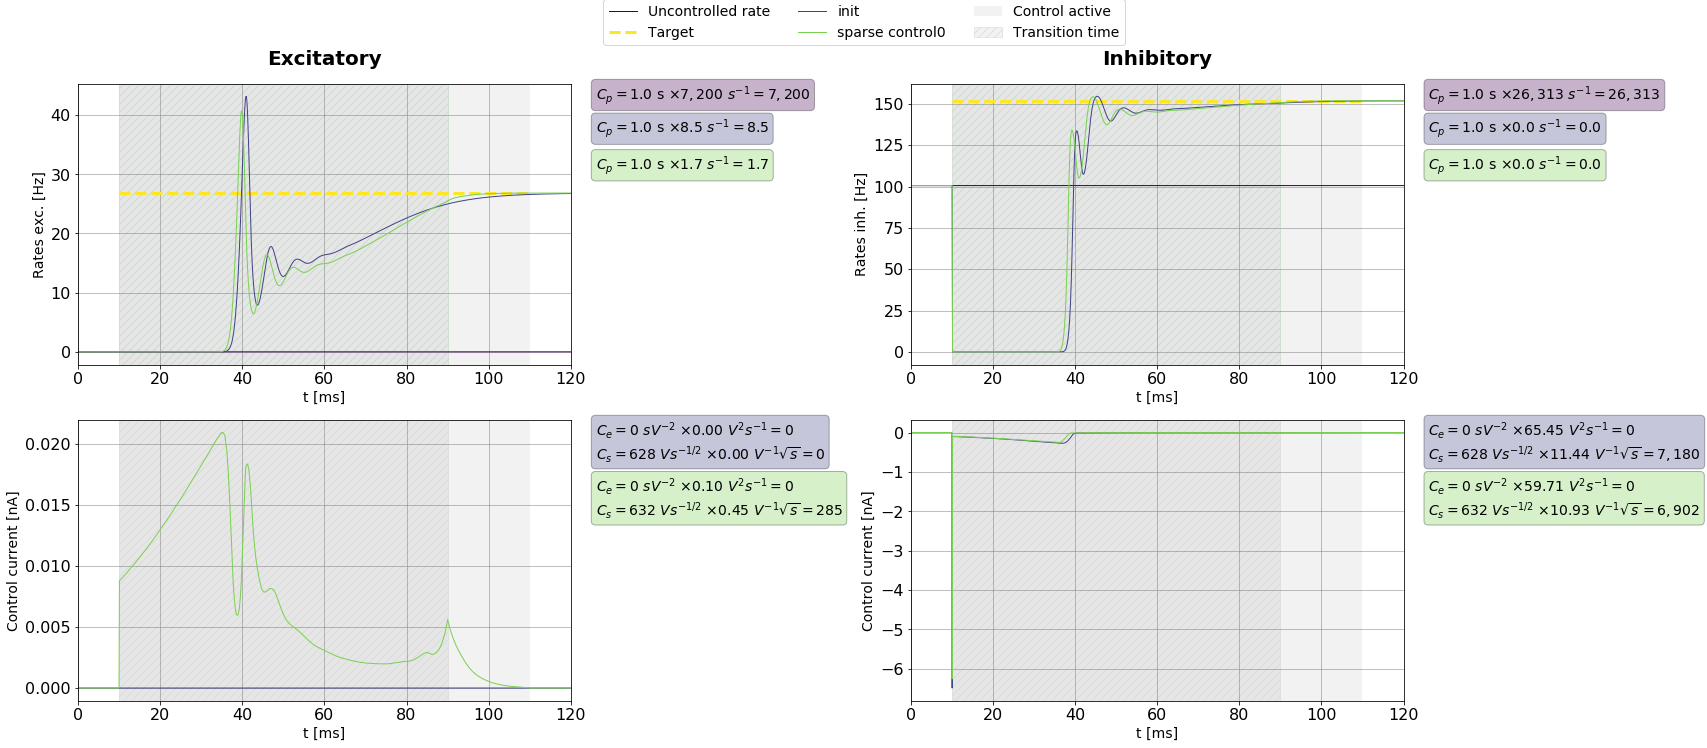

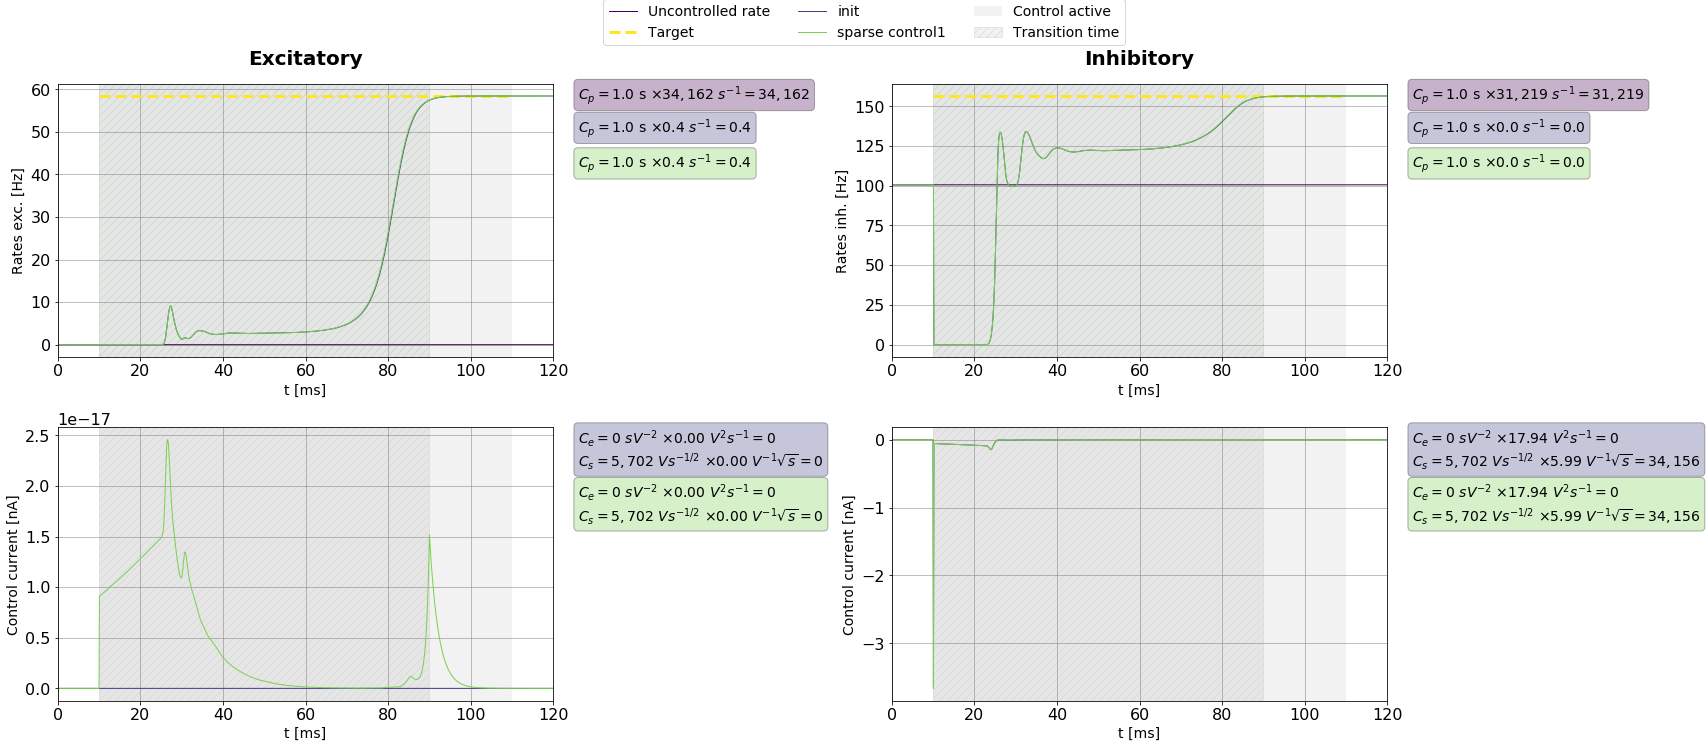

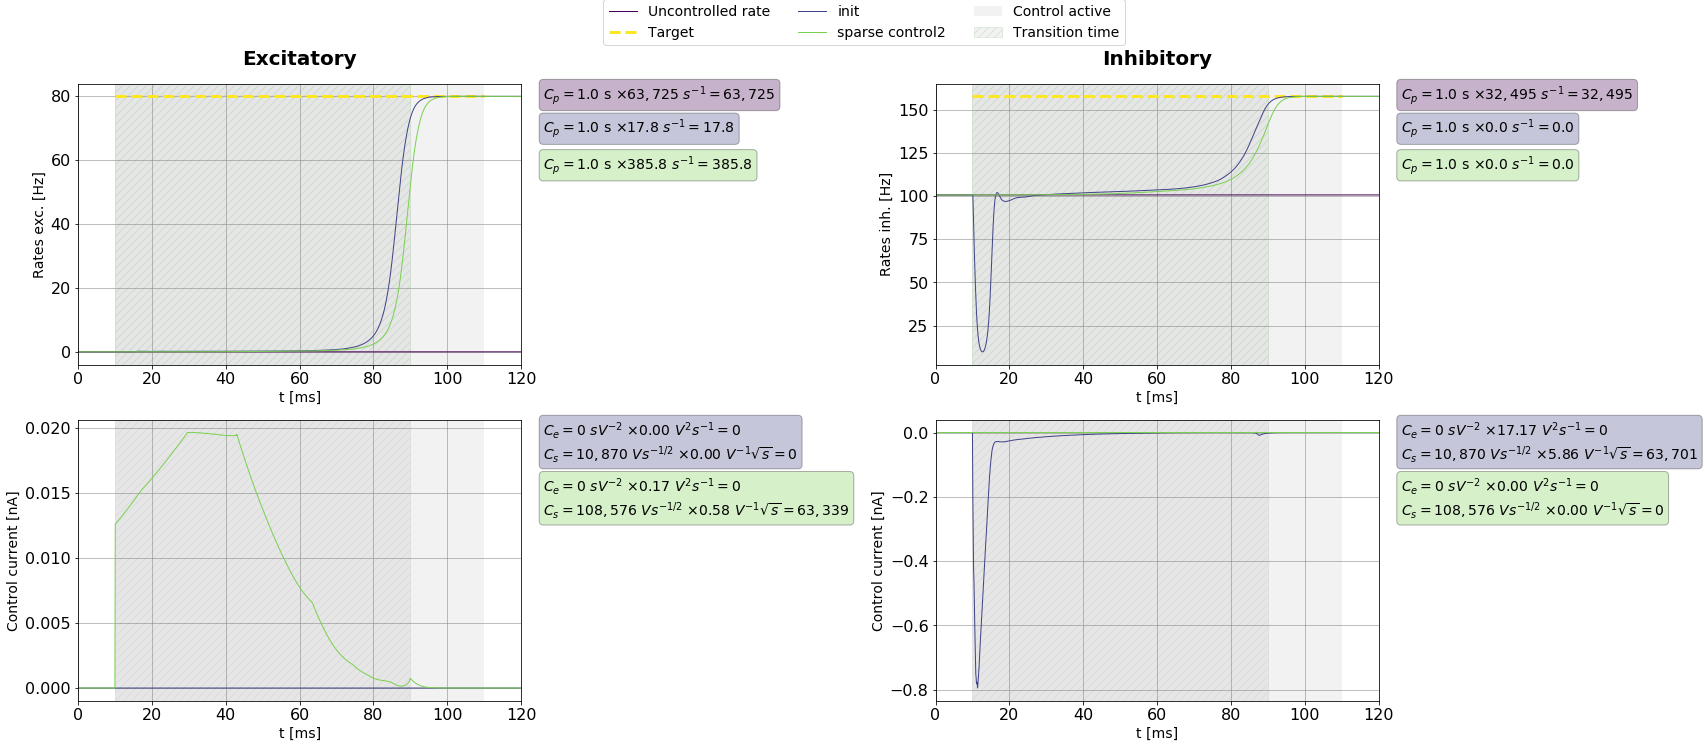

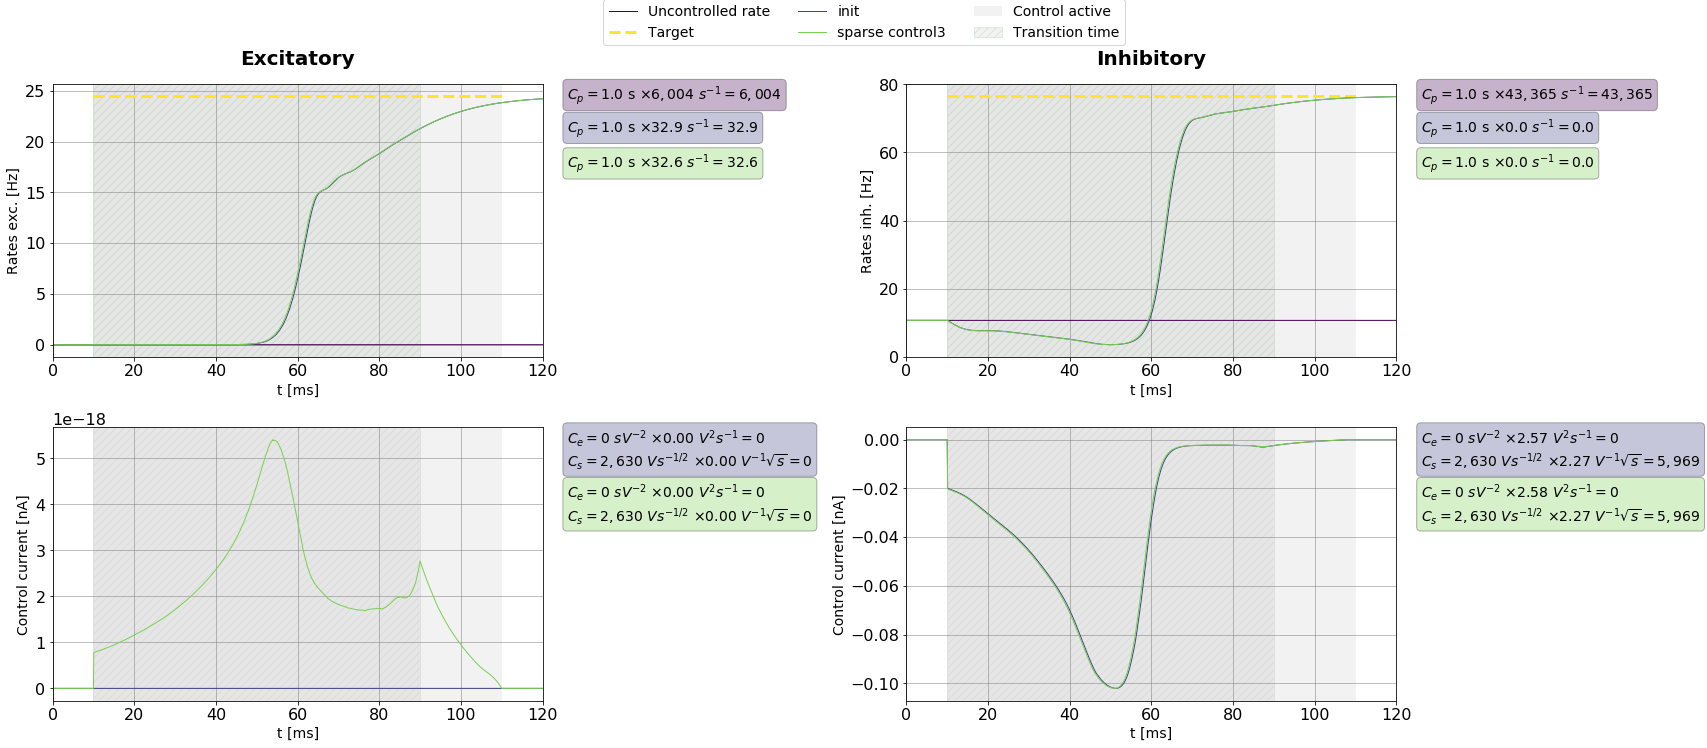

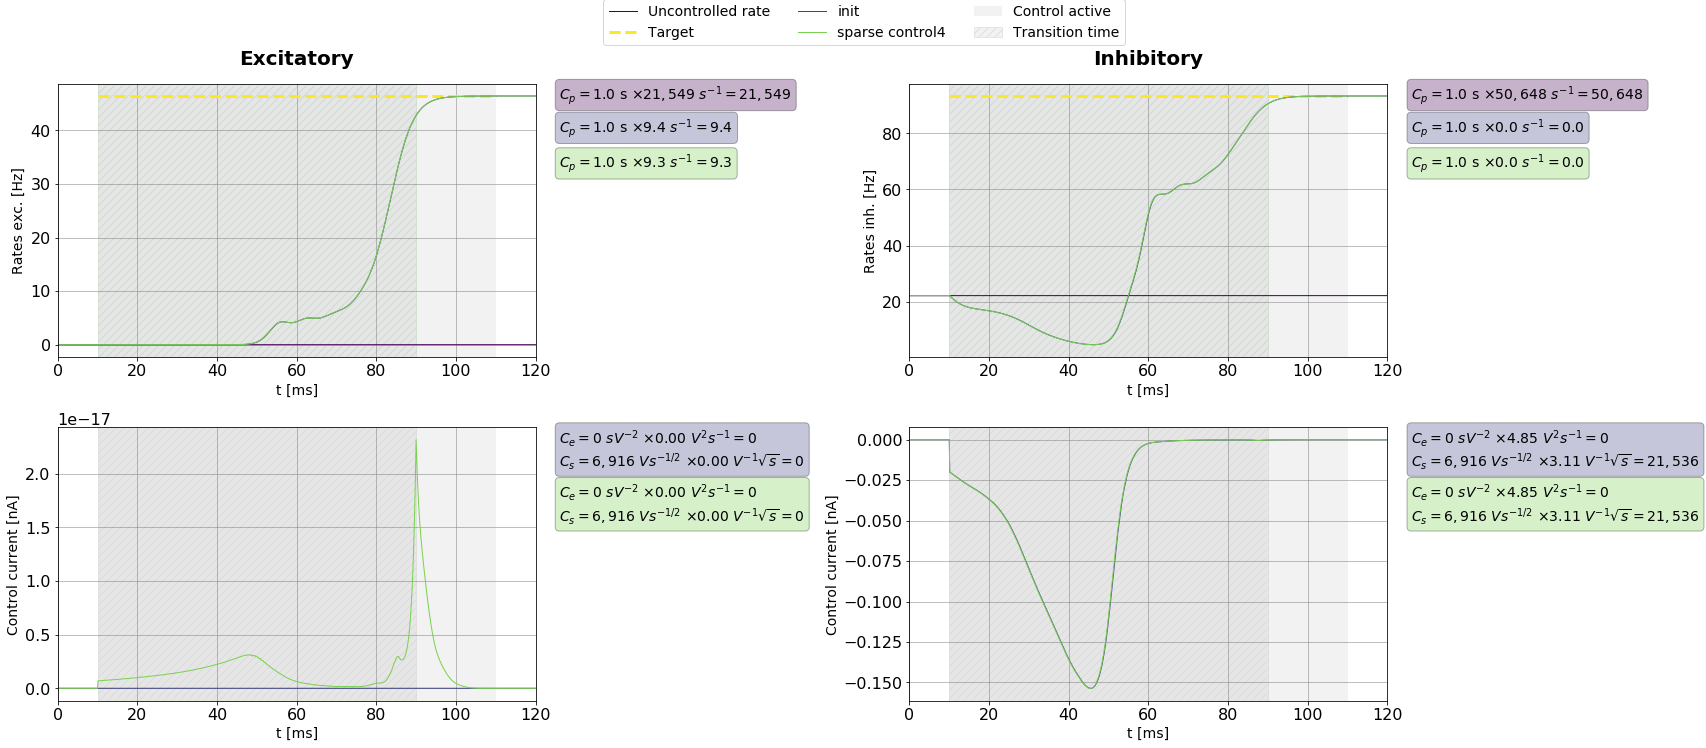

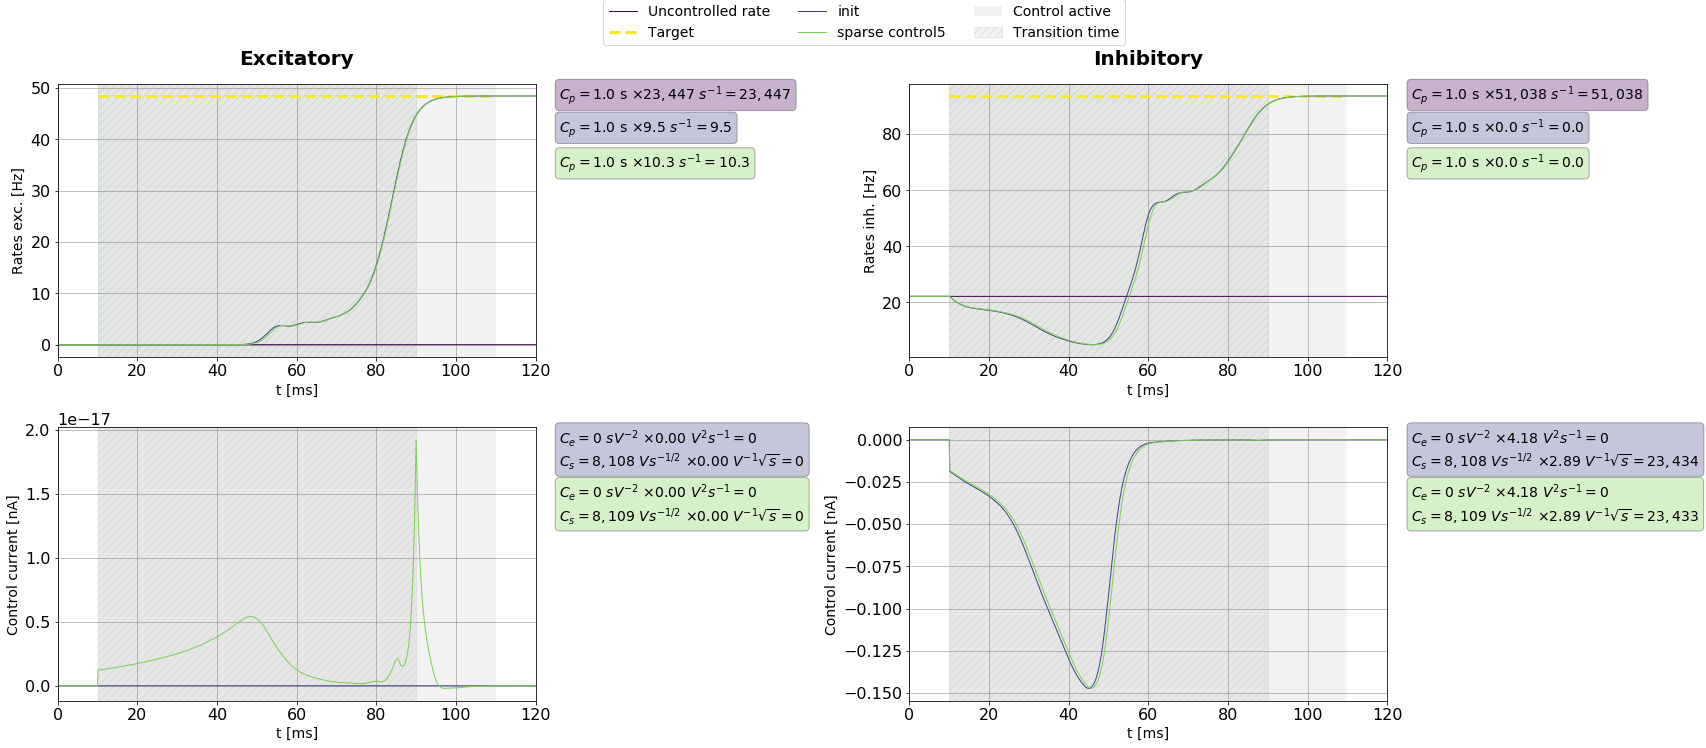

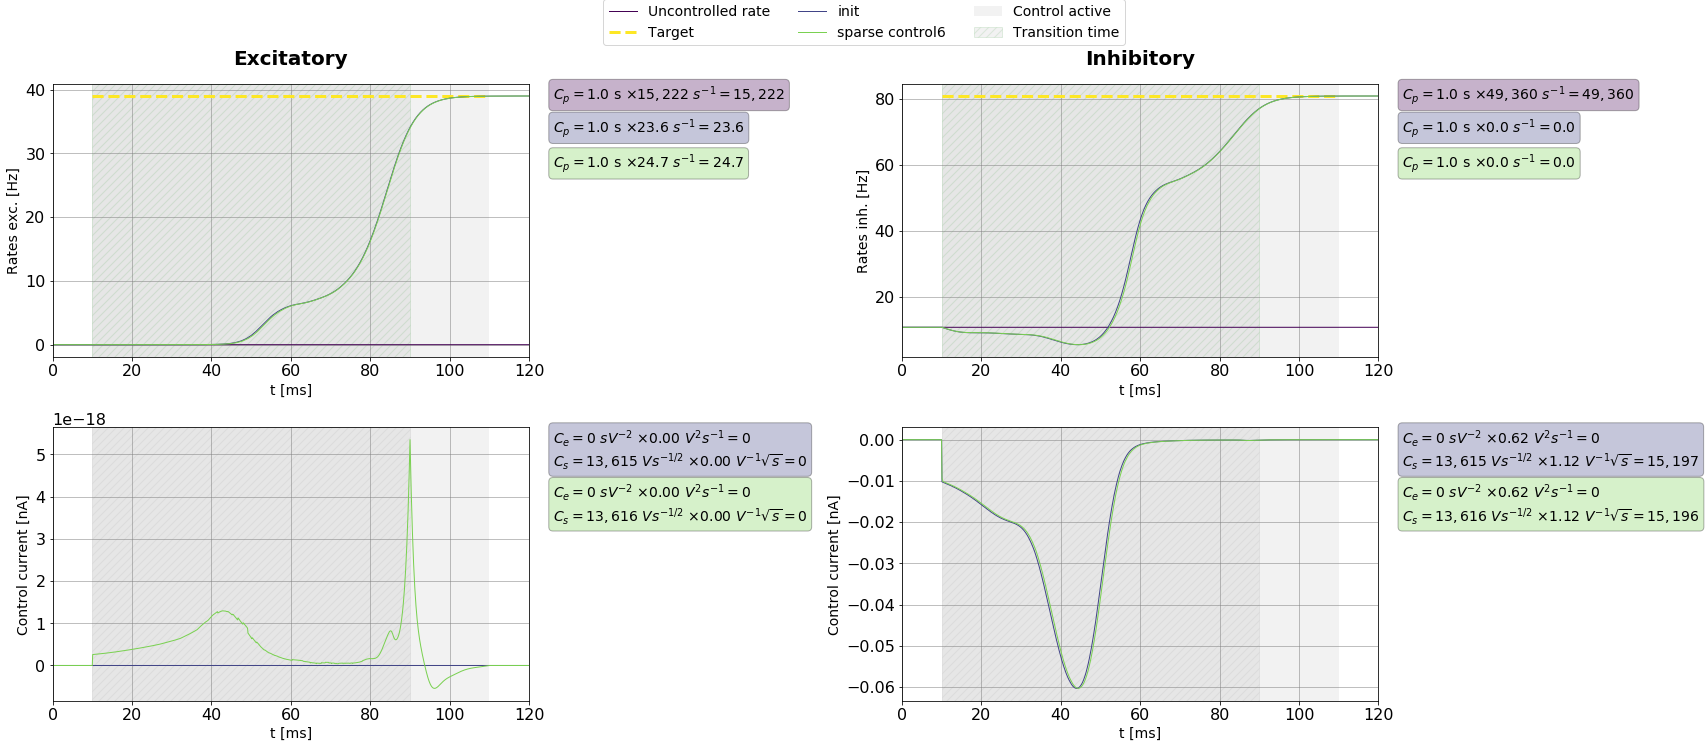

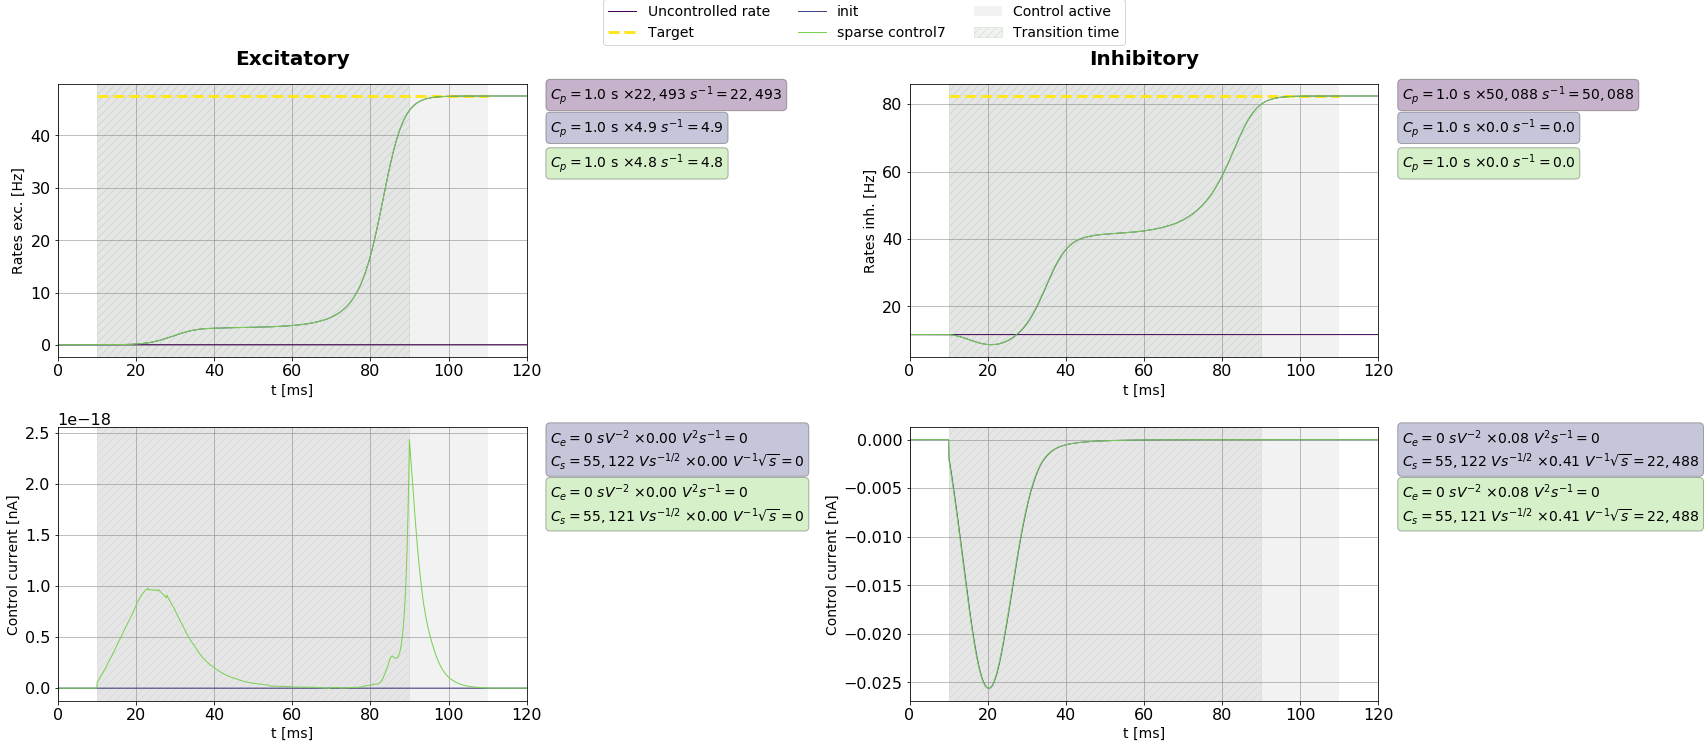

In [155]:
for i in i_range:
    
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], path, filename_ = case, transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)])

In [154]:
factor_iteration = 2
    
for i in i_range:
    
    print("------- ", i, params_bistability_exc[i], params_bistability_inh[i])
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 250 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 2.2 5.0
weight sparsity =  631.5506716177218
set cost params:  1.0 0.0 631.5506716177218
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7188.6350286804345
Gradient descend method:  None
RUN  1 , total integrated cost =  7188.635028680434
RUN  2 , total integrated cost =  7188.635028680432
RUN 

ERROR:root:Problem in initial value trasfer


 3 , total integrated cost =  7188.635028680432
Control only changes marginally.
RUN  3 , total integrated cost =  7188.635028680432
Improved over  3  iterations in  0.757495600000766  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -55.589913486244846 -55.58991183486751
-------  1 2.9 5.0
weight sparsity =  5702.225042120199
set cost params:  1.0 0.0 5702.225042120199
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34156.31683679622
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  34156.31683679622
Control only changes marginally.
RUN  1 , total integrated cost =  34156.31683679622
Improved over  1  iterations in  0.3325413999991724  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.28941638092144 -56.289416413565476
-------  2 3.55 5.0
weight sparsity =  108576.34174143983
set cost params:  1.0 0.0 108576.34174143983
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63724.62032268835
Gradient descend method:  None


...

RUN  1 , total integrated cost =  23443.71844967488
Control only changes marginally.
RUN  1 , total integrated cost =  23443.71844967488
Improved over  1  iterations in  0.26473489999989397  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.186916417268066 -56.186917389653175
-------  6 2.3000000000000003 2.0
weight sparsity =  13615.970303759997
set cost params:  1.0 0.0 13615.970303759997
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15220.69090128678
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  15220.69090128678
Control only changes marginally.
RUN  1 , total integrated cost =  15220.69090128678
Improved over  1  iterations in  0.26060140000117826  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.01811259782255 -56.018126030540344
-------  7 2.5 2.0
weight sparsity =  55121.19318355661
set cost params:  1.0 0.0 55121.19318355661
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.086035023687
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.086035023684


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  22493.086035023684
Control only changes marginally.
RUN  2 , total integrated cost =  22493.086035023684
Improved over  2  iterations in  0.49227499999869906  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.174576075937004 -56.17457666486646


In [144]:
with open('control_0_lh_inhinit.pickle','wb') as f:
    pickle.dump([bestControl_0, costnode_0, weights_0], f)
    
with open('control_0_lh_inhinit.pickle','rb') as f:
    load_array = pickle.load(f)
    
print(len(load_array))

#bestControl_0 = load_array[0]
#costnode_0 = load_array[1]
#weights_0 = load_array[2]

3


In [171]:
not_checked = []
exc_ = []
inh_ = []
e_i = []

for i in range(len(params_bistability_exc)):
    if type(bestControl_0[i]) is type(None):
        print(i, " not checked yet")
        not_checked.append(i)
        continue
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        inh_.append(i)
        print(i, " only inhibitory current")
    elif np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8:
        exc_.append(i)
        print(i, " only excitatory current")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8:
        print(i, "no control input")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        print(i, " control input in both nodes")
        e_i.append(i)
    else:
        print(i, " no category")
        
print(exc_, inh_, e_i)

0  control input in both nodes
1  only inhibitory current
2  only excitatory current
3  only inhibitory current
4  only inhibitory current
5  only inhibitory current
6  only inhibitory current
7  only inhibitory current
[2] [1, 3, 4, 5, 6, 7] [0]


In [157]:
boundary_x = [3.65, 3.5999999999999996, 3.55, 3.5, 3.4499999999999997, 3.4000000000000004, 3.35, 3.3000000000000003, 3.25, 3.2, 3.15, 3.1, 3.05, 3.0, 2.9499999999999997, 2.9, 2.8499999999999996, 2.8000000000000003, 2.75, 2.7, 2.6500000000000004, 2.6, 2.55, 2.5, 2.45, 2.4, 2.3499999999999996, 2.3000000000000003, 2.25, 2.2, 2.15, 2.1, 2.05, 2.0, 2.0, 2.0, 2.0, 2.0, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.05, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.15, 2.15, 2.15, 2.15, 2.15, 2.15, 2.15, 2.15, 2.15, 2.2, 2.2, 2.2, 2.2]
boundary_y = [7.4, 5.45, 4.5, 3.95, 3.55, 3.3000000000000003, 3.1, 2.9499999999999997, 2.8000000000000003, 2.7, 2.6, 2.5, 2.45, 2.4, 2.3499999999999996, 2.25, 2.2, 2.15, 2.1, 2.1, 2.05, 2.05, 2.0, 2.0, 1.9500000000000002, 1.9500000000000002, 1.9, 1.85, 1.85, 1.85, 1.7999999999999998, 1.75, 1.75, 1.7000000000000002, 1.75, 1.7999999999999998, 1.85, 1.9, 1.9500000000000002, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3000000000000003, 2.3499999999999996, 2.4, 2.45, 2.5, 2.55, 2.6, 2.75, 3.0, 3.25, 3.4000000000000004, 3.4499999999999997, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.3500000000000005, 5.4, 5.8999999999999995, 6.4, 6.8999999999999995]

3 2.7025153245790902e-17 -0.5100471120108847
4 1.1580541505300124e-16 -0.7681078263035755
5 9.617134413570281e-17 -0.735516224143557
6 2.6743683315312558e-17 -0.3015383222313587
7 1.2151206082997204e-17 -0.1280951099105436
0.10457685880642288 -31.27628023623431


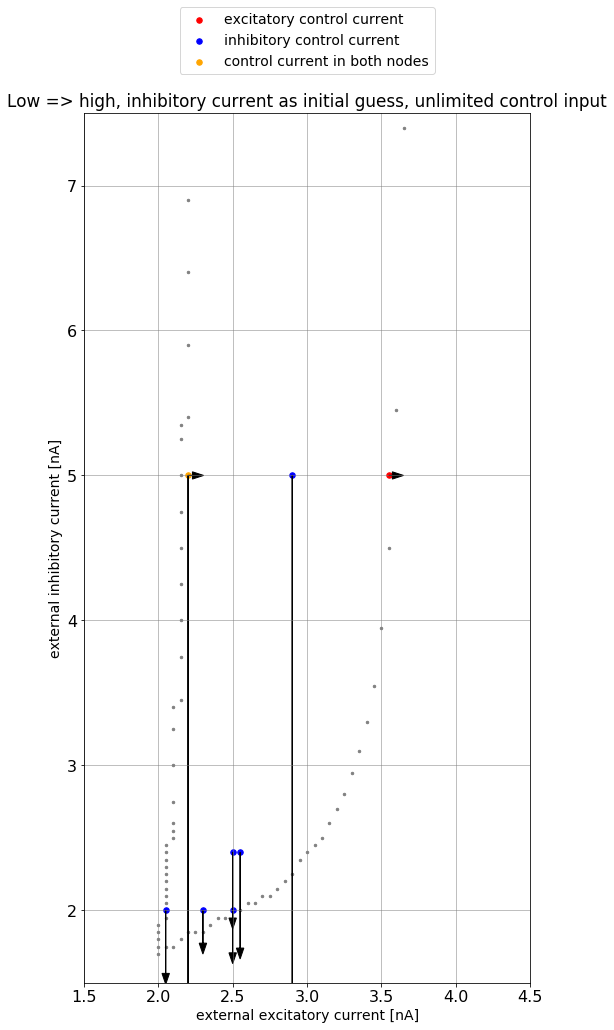

In [193]:
yshift = [0,0.0,0.,0,0,0.0,0.0,0.]
plt.figure(figsize=(8,16))  
plt.title("Low => high, inhibitory current as initial guess, unlimited control input")

for j in range(len(boundary_x)):
    plt.scatter(boundary_x[j], boundary_y[j], s=6, c="grey")

if len(exc_) > 0:
    plt.scatter(params_bistability_exc[exc_[0]], params_bistability_inh[exc_[0]], s=30, c="red",
                label="excitatory control current")
    lenx = np.amax(bestControl_0[exc_[0]][0,0,:])
    if np.abs(np.amin(bestControl_0[exc_[0]][0,0,:])) > np.abs(lenx):
        lenx = np.amin(bestControl_0[exc_[0]][0,0,:])
    leny = np.amax(bestControl_0[exc_[0]][0,1,:])
    if np.abs(np.amin(bestControl_0[exc_[0]][0,1,:])) > np.abs(leny):
        leny = np.amin(bestControl_0[exc_[0]][0,1,:])
    plt.arrow(params_bistability_exc[exc_[0]], params_bistability_inh[exc_[0]], lenx, leny,
              head_width=0.05, length_includes_head= True, color="black")
if len(exc_) > 1:
    for i in exc_[1:]:
        plt.scatter(params_bistability_exc[i], params_bistability_inh[i], s=30, c="red")
        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
    if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
        leny = np.amin(bestControl_0[i][0,1,:])
        plt.arrow(params_bistability_exc[i], params_bistability_inh[i] + yshift[i], lenx, leny,
                  head_width=0.05, length_includes_head= True, color="black")

if len(inh_) > 0:
    plt.scatter(params_bistability_exc[inh_[0]], params_bistability_inh[inh_[0]], s=30, c="blue",
                label="inhibitory control current")
    lenx = np.amax(bestControl_0[inh_[0]][0,0,:])
    if np.abs(np.amin(bestControl_0[inh_[0]][0,0,:])) > np.abs(lenx):
        lenx = np.amin(bestControl_0[inh_[0]][0,0,:])
    leny = np.amax(bestControl_0[inh_[0]][0,1,:])
    if np.abs(np.amin(bestControl_0[inh_[0]][0,1,:])) > np.abs(leny):
        leny = np.amin(bestControl_0[inh_[0]][0,1,:])
    plt.arrow(params_bistability_exc[inh_[0]], params_bistability_inh[inh_[0]], lenx, leny,
              head_width=0.05, length_includes_head= True, color="black")
if len(inh_) > 1:
    for i in inh_[1:]:
        plt.scatter(params_bistability_exc[i], params_bistability_inh[i], s=30, c="blue")
        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        print(i,lenx,leny)
        plt.arrow(params_bistability_exc[i], params_bistability_inh[i] + yshift[i], lenx, leny,
                head_width=0.05, length_includes_head= True, color="black")
        
if len(e_i) > 0:
    plt.scatter(params_bistability_exc[e_i[0]], params_bistability_inh[e_i[0]], s=30, c="orange",
                label="control current in both nodes")
    lenx = np.amax(bestControl_0[e_i[0]][0,0,:])
    if np.abs(np.amin(bestControl_0[e_i[0]][0,0,:])) > np.abs(lenx):
        lenx = np.amin(bestControl_0[e_i[0]][0,0,:])
    leny = np.amax(bestControl_0[e_i[0]][0,1,:])
    if np.abs(np.amin(bestControl_0[e_i[0]][0,1,:])) > np.abs(leny):
        leny = np.amin(bestControl_0[e_i[0]][0,1,:])
    print(lenx,leny)
    plt.arrow(params_bistability_exc[e_i[0]], params_bistability_inh[e_i[0]], lenx, 0,
              head_width=0.05, length_includes_head= True, color="black")
    plt.arrow(params_bistability_exc[e_i[0]], params_bistability_inh[e_i[0]], 0, leny,
              head_width=0.05, length_includes_head= True, color="black")
if len(e_i) > 1:
    for i in e_i[1:]:
        plt.scatter(params_bistability_exc[i], params_bistability_inh[i], s=30, c="orange")
        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        plt.arrow(params_bistability_exc[i], params_bistability_inh[i] + yshift[i], lenx, 0,
                head_width=0.05, length_includes_head= True, color="black")
        plt.arrow(params_bistability_exc[i], params_bistability_inh[i] + yshift[i], 0, leny,
                head_width=0.05, length_includes_head= True, color="black")

plt.xlabel("external excitatory current [nA]")
plt.ylabel("external inhibitory current [nA]")
plt.xlim([1.5,4.5])
plt.ylim([1.5,7.5])
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13))
plt.savefig("b_2")
plt.show()

In [272]:
for c_ in np.arange(0.43, 0.61, 0.01):
    c_e = c_ * 5.
    c_i = 0.51 * 5.

    params_bistability_exc.append(c_e)
    params_bistability_inh.append(c_i)

    bestControl_init.append(None)
    bestState_init.append(None)
    cost_init.append(None)
    runtime_init.append(None)
    grad_init.append(None)
    phi_init.append(None)
    costnode_init.append(None)
    weights_init.append(None)

    initVars.append(None)
    target.append(None)
    cost_uncontrolled.append(None)

    bestControl_0.append(None)
    bestState_0.append(None)
    cost_0.append(None)
    runtime_0.append(None)
    grad_0.append(None)
    phi_0.append(None)
    costnode_0.append(None)
    weights_0.append(None)

In [261]:
print(params_bistability_inh[-2]/5.)

0.4699999999999999


In [142]:
bestControl_init.pop()
bestState_init.pop()
cost_init.pop()
runtime_init.pop()
grad_init.pop()
phi_init.pop()
costnode_init.pop()
weights_init.pop()

initVars.pop()
target.pop()
cost_uncontrolled.pop()

bestControl_0.pop()
bestState_0.pop()
cost_0.pop()
runtime_0.pop()
grad_0.pop()
phi_0.pop()
costnode_0.pop()
weights_0.pop()

[None]

In [ ]:
# basin of attraction for initial parameters as in high state (except for rates)

i_range = range(len(params_bistability_exc))

factor_iteration = 2

for i in i_range:
    print("------- ", i, params_bistability_exc[i], params_bistability_inh[i])
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = step_control(maxI_ = -3.)

    plotFunc.plot_traces(aln, control0)
    
    steady_rates = np.zeros((2, 2))
    steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
    steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh

    control0 = step_control(maxI_ = 3.)
    plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")
    
    steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
    steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh

    high_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            high_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            high_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = high_state_vars
    
